<a href="https://colab.research.google.com/github/skurakake/MMP_public/blob/main/VGGNet_c100_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
# cifar100 を使う
from tensorflow.keras.datasets import cifar100

(x_train, t_train), (x_test, t_test) = cifar100.load_data(label_mode='fine')


CIFAR100_LABELS_LIST = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman',
    'worm'
]

num_category = 100 # クラス数

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


x_train shape: (50000, 32, 32, 3)
the number of train samples: 50000
the number of test samples: 10000
<class 'numpy.ndarray'>
(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


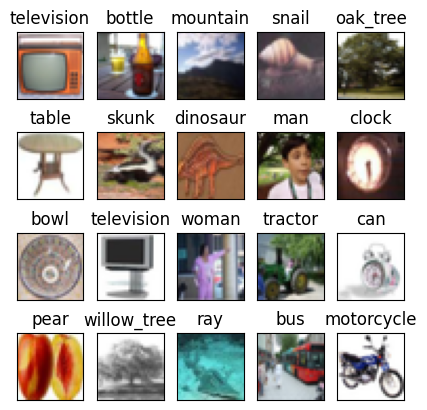

In [3]:
# ダウンロードしたデータの一部をランダムに表示

print('x_train shape:', x_train.shape)
print('the number of train samples:', x_train.shape[0] )
print('the number of test samples:', x_test.shape[0] )
print(type(x_train[0]))

print(x_train.shape, t_train.shape)
print(x_test.shape, t_test.shape)
print(type(x_test))
print(type(t_test[0]))


num_image = 20 # 表示数
rand_idx = np.random.randint(0, len(x_train), num_image)
plt.figure(figsize=(5, 5)) # 表示領域のサイズ
# plt figure set to 5inch x 5inch(500pixel x 500 pixel).

labels = CIFAR100_LABELS_LIST
for i in range(num_image):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[rand_idx[i]])
    plt.title(labels[t_train[rand_idx[i]][0]])
    plt.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)

plt.show() # 実行されたとき始めてウィンドウが立ち上がり、そのウィンドウに図が表示される
# colab では plt.show() がなくても、環境が自動でウィンドウをオープンしてくれるが、
# コマンドラインとかでは、これが必要

In [4]:
# 設定
batch_size = 32 # ミニバッチサイズ
epochs = 25 # エポック数
num_class = 100 # クラス数

# 正解データを one-hot 表現へ変換
t_train_n = tf.keras.utils.to_categorical(t_train, num_class)
t_test_n = tf.keras.utils.to_categorical(t_test, num_class)
print("正解データ（学習）：", t_train_n[:2])
print("正解データ（テスト）：", t_test_n[:2])

正解データ（学習）： [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]]
正解データ（テスト）： [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

モデルの構築

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Activation, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization, Resizing, Rescaling
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD

model = Sequential()

model.add(Input(shape=x_train.shape[1:]))# .shape の2番目から最後までの要素 (32,32,3)
#model.add(Resizing(32, 32))
model.add(Rescaling(1./255))
model.add(Conv2D(64,(3,3), strides=1,  padding = 'same')) #padding = 'same' 入力と同じサイズになるまで０パディング
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(64,(3,3), strides=1,  padding = 'same')) #padding = 'same' 入力と同じサイズになるまで０パディング
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2))

model.add(Conv2D(128,(3,3), strides=1,  padding = 'same')) #padding = 'same' 入力と同じサイズになるまで０パディング
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(128,(3,3), strides=1,  padding = 'same')) #padding = 'same' 入力と同じサイズになるまで０パディング
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2))

model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(4096))
model.add(Dropout(0.5))
model.add(Dense(4096))
model.add(Dense(num_class))
model.add(Activation('softmax'))

model.compile(loss='categorical_crossentropy', optimizer=SGD(), metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    33,558,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       409,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 100)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,011,236 (194.59 MB)

 Trainable params: 51,010,468 (194.59 MB)

 Non-trainable params: 768 (3.00 KB)

モデルを訓練する

In [6]:
history = model.fit(x_train, t_train_n, batch_size=batch_size,
                    epochs=epochs, validation_data=(x_test, t_test_n))

Epoch 1/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.1088 - loss: 4.2278 - val_accuracy: 0.2005 - val_loss: 3.3695
Epoch 2/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.2175 - loss: 3.2803 - val_accuracy: 0.2790 - val_loss: 2.9380
Epoch 3/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.2856 - loss: 2.9164 - val_accuracy: 0.3269 - val_loss: 2.7315
Epoch 4/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.3349 - loss: 2.6532 - val_accuracy: 0.3545 - val_loss: 2.5759
Epoch 5/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.3781 - loss: 2.4475 - val_accuracy: 0.3848 - val_loss: 2.4234
Epoch 6/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.4153 - loss: 2.2623 - val_accuracy: 0.4184 - val_loss: 2.2759
Epoch 7/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.4459 - loss: 2.1209 - val_accuracy: 0.4580 - val_loss: 2.1061
Epoch 8/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.4750 -

In [1]:
# 学習の経過をグラフで表示
import matplotlib.pyplot as plt
train_loss = history.history['loss']
train_accuracy = history.history['accuracy']
validation_loss = history.history['val_loss']
validation_accuracy = history.history['val_accuracy']

plt.plot(np.arange(len(train_loss)), train_loss, label='training_loss')
plt.plot(np.arange(len(validation_loss)), validation_loss, label='validation_loss')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper right')
plt.show()

plt.plot(np.arange(len(train_accuracy)), train_accuracy, label='training_accuracy')
plt.plot(np.arange(len(validation_accuracy)), validation_accuracy, label='validation_accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

NameError: name 'history' is not defined

テストデータ全体に対して精度とlossを求める

In [ ]:
loss, accuracy = model.evaluate(x_test, t_test_n)
print('Test loss:', loss)
print('Test accuracy:', accuracy)

学習済みのモデルを使って、テストデータの中からランダムに選択したデータに対して分類を行う。

In [ ]:
num2_image = 20
rand_idx2 = np.random.randint(0, len(x_test), num2_image)

y_rand = model.predict(x_test[rand_idx2]) # テストデータからランダムに画像を選択して、画像分類を実行
predicted_class = np.argmax(y_rand, axis=1) # 分類結果の中で最大値を取るインデックスを取得

plt.figure(figsize=(16,16)) # 画像の表示サイズ

for i in range(num2_image):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[rand_idx2[i]])
    label = CIFAR100_LABELS_LIST[predicted_class[i]]
    plt.title(label)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

plt.show()


学習済みのモデルをgoogle drive に保存

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

In [ ]:
import os
from keras.models import load_model

path = '/content/drive/MyDrive/Colab Notebooks/'

if not os.path.exists(path):
    os.makedirs(path)

#
model.save(path + "model_VGGNet_c100_2.keras")